## Code for MMCP'24 conference presentation

### functions

In [1]:
from itertools import chain, product

import sympy as sp
from sympy.abc import c, epsilon, mu, omega, t, x, y, z
from sympy.solvers.ode.systems import dsolve_system
from sympy.vector import CoordSys3D, Del
from sympy.solvers.ode.systems import linear_ode_to_matrix

from preview_wrappers import preview_collection, save_latex_as_image
from solveHomoSLAE import solve_all


def gen_vars_subs(U_symbols, args_before, args_after):
    return {
        U(*args_before): U(*args_after) for U in list(chain.from_iterable(U_symbols))
    }


def gen_subs_diff(R, U_comps):
    return {
        value.diff(key): 0
        for key, value in list(product([R.y, R.z], list(U_comps.components.values())))
    }


def list_subs(eqs: list, subs: dict, eval=True):
    if eval is True:
        return list(map(lambda eq: eq.subs(subs).expand().simplify(), eqs))
    else:
        return list(map(lambda eq: eq.subs(subs), eqs))


def check_sols(eqs, sols):
    sols_subs = {sol.lhs: sol.rhs for sol in sols}
    return list_subs(eqs, sols_subs)


def gen_vector_field_symbols(R, order=0):
    E_symbols = [
        [sp.Function(f"E^{comp}_{i}") for comp in [x, y, z]] for i in range(order + 1)
    ]
    E_vec_comps = [
        Ex(R.x, R.y, R.z) * R.i + Ey(R.x, R.y, R.z) * R.j + Ez(R.x, R.y, R.z) * R.k
        for Ex, Ey, Ez in E_symbols
    ]
    H_symbols = [
        [sp.Function(f"H^{comp}_{i}") for comp in [x, y, z]] for i in range(order + 1)
    ]
    H_vec_comps = [
        Hx(R.x, R.y, R.z) * R.i + Hy(R.x, R.y, R.z) * R.j + Hz(R.x, R.y, R.z) * R.k
        for Hx, Hy, Hz in H_symbols
    ]
    E_asympt = [
        sum(
            map(
                lambda k, vec: vec / (sp.I * omega) ** k,
                range(s + 1),
                E_vec_comps,
            ),
            0 * R.i,
        )
        for s in range(order + 1)
    ]  # 0*R.i determines return type
    H_asympt = [
        sum(
            map(
                lambda k, vec: vec / (sp.I * omega) ** k,
                range(s + 1),
                H_vec_comps,
            ),
            0 * R.i,
        )
        for s in range(order + 1)
    ]
    return E_symbols, H_symbols, E_vec_comps, H_vec_comps, E_asympt, H_asympt


def gen_maxwell_eqs(
    R,
    delop,
    phi,
    E_symbols,
    H_symbols,
    E_vec_comps,
    H_vec_comps,
    E_asympt,
    H_asympt,
    order=0,
    prev_order_eqs=None,
):
    curl_E = (
        (
            (
                delop.cross(
                    E_asympt[order]
                    * sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
                )
                + mu
                / c
                * (
                    H_asympt[order]
                    * sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
                ).diff(t)
            )
            .doit()
            .to_matrix(R)
            / sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
        )
        .expand()
        .subs(gen_subs_diff(R, E_vec_comps[order]))
    )

    curl_H = (
        (
            (
                delop.cross(
                    H_asympt[order]
                    * sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
                )
                - epsilon
                / c
                * (
                    E_asympt[order]
                    * sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
                ).diff(t)
            )
            .doit()
            .to_matrix(R)
            / sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
        )
        .expand()
        .subs(gen_subs_diff(R, H_vec_comps[order]))
    )

    maxwell_eqs = list_subs(
        [sp.Eq(eq, 0) for eq in list(curl_E) + list(curl_H)],
        {R.x: x, R.y: y, R.z: z},
        eval=False,
    )

    if prev_order_eqs is not None:
        maxwell_eqs = [
            sp.Eq((maxwell_eqs[i].lhs - prev_order_eqs[i].lhs).expand(), 0)
            for i in range(6)
        ]

    maxwell_alg_eqs = [
        sp.Eq(
            E_symbols[order][0](x, y, z),
            sp.solve(maxwell_eqs[3], E_symbols[order][0](x, y, z))[0],
        ),
        sp.Eq(
            H_symbols[order][0](x, y, z),
            sp.solve(maxwell_eqs[0], H_symbols[order][0](x, y, z))[0],
        ),
    ]

    maxwell_diff_eqs = list(
        filter(
            lambda x: x is not (sp.sympify(True) or 0),
            list_subs(maxwell_eqs, {eq.lhs: eq.rhs for eq in maxwell_alg_eqs}),
        )
    )
    return maxwell_eqs, maxwell_alg_eqs, maxwell_diff_eqs


def layered_sols(sols, layer_symbol, order) -> list:
    # TODO: add a param to signal what exponents (with `+` or `-`) to omit
    # WARNING: order of substituting symbols here is "hard-coded" for author's convenience
    if order > 0:
        prev_U_subs = {
            sp.Function("E^x_0")(x, z): sp.Function(f"E^{{x,{layer_symbol}}}_{0}")(
                x, z
            ),
            sp.Function("E^y_0")(x, z): sp.Function(f"E^{{y,{layer_symbol}}}_{0}")(
                x, z
            ),
            sp.Function("E^z_0")(x, z): sp.Function(f"E^{{z,{layer_symbol}}}_{0}")(
                x, z
            ),
            sp.Function("H^x_0")(x, z): sp.Function(f"H^{{x,{layer_symbol}}}_{0}")(
                x, z
            ),
            sp.Function("H^y_0")(x, z): sp.Function(f"H^{{y,{layer_symbol}}}_{0}")(
                x, z
            ),
            sp.Function("H^z_0")(x, z): sp.Function(f"H^{{z,{layer_symbol}}}_{0}")(
                x, z
            ),
        }
    else:
        prev_U_subs = dict()

    U_p_subs = {
        sp.Function(f"{U}^{{{i}}}_p")(x, z): sp.Function(
            f"{U}^{{{i},{layer_symbol}}}_p"
        )(x, z)
        for U, i in product(["E", "H"], [x, y, z])
    }

    match layer_symbol:
        case "c":
            # x -> x - h(z) eases calculation (only for 0-order for now)
            if order == 0:
                sols = [
                    sol.replace(
                        sp.exp,
                        lambda arg: sp.exp(arg.subs({x: x - sp.Function("h")(z)})),
                    )
                    for sol in sols
                ]

            sols = list_subs(
                sols,
                {
                    sp.Symbol("C1"): sp.Symbol(f"A_{order}^{layer_symbol}"),
                    sp.Symbol("C2"): 0,
                    sp.Symbol("C3"): sp.Symbol(f"B_{order}^{layer_symbol}"),
                    sp.Symbol("C4"): 0,
                }
                | prev_U_subs
                | U_p_subs,
                eval=False,
            )

        case "f":
            sols = list_subs(
                sols,
                {
                    sp.Symbol("C1"): sp.Symbol(f"A_{order}^{layer_symbol}"),
                    sp.Symbol("C2"): sp.Symbol(f"B_{order}^{layer_symbol}"),
                    sp.Symbol("C3"): sp.Symbol(f"C_{order}^{layer_symbol}"),
                    sp.Symbol("C4"): sp.Symbol(f"D_{order}^{layer_symbol}"),
                }
                | prev_U_subs
                | U_p_subs,
                eval=False,
            )

        case "s":
            sols = list_subs(
                sols,
                {
                    sp.Symbol("C1"): 0,
                    sp.Symbol("C2"): sp.Symbol(f"A_{order}^{layer_symbol}"),
                    sp.Symbol("C3"): 0,
                    sp.Symbol("C4"): sp.Symbol(f"B_{order}^{layer_symbol}"),
                }
                | prev_U_subs
                | U_p_subs,
                eval=False,
            )

    return [
        sol.xreplace(
            {
                sol.lhs: comp,
                epsilon: sp.Symbol(f"epsilon_{layer_symbol}"),
                mu: sp.Symbol(f"mu_{layer_symbol}"),
                sp.Function("eta")(z): sp.Function(f"eta_{layer_symbol}")(z),
                sp.Function("gamma")(z): sp.Function(f"gamma_{layer_symbol}")(z),
                sp.Function("gammatilde")(z): sp.Function(f"gammatilde_{layer_symbol}")(
                    z
                ),
            }
        )
        for sol, comp in zip(
            sols,
            [
                sp.Function(f"E^{{x,{layer_symbol}}}_{order}")(x),
                sp.Function(f"E^{{y,{layer_symbol}}}_{order}")(x),
                sp.Function(f"E^{{z,{layer_symbol}}}_{order}")(x),
                sp.Function(f"H^{{x,{layer_symbol}}}_{order}")(x),
                sp.Function(f"H^{{y,{layer_symbol}}}_{order}")(x),
                sp.Function(f"H^{{z,{layer_symbol}}}_{order}")(x),
            ],
        )
    ]


def gen_boundry_conds(R, delop, U, border_func, border_func_value, layers, order):
    normal = delop(border_func).doit()
    char_U = str(list(U.components.values())[0])[0]
    nU_1 = normal.cross(U).subs(
        {
            U.components[R.i]: sp.Function(f"{char_U}^{{x,{layers[0]}}}_{order}")(x),
            U.components[R.j]: sp.Function(f"{char_U}^{{y,{layers[0]}}}_{order}")(x),
            U.components[R.k]: sp.Function(f"{char_U}^{{z,{layers[0]}}}_{order}")(x),
        }
    )

    nU_2 = normal.cross(U).subs(
        {
            U.components[R.i]: sp.Function(f"{char_U}^{{x,{layers[1]}}}_{order}")(x),
            U.components[R.j]: sp.Function(f"{char_U}^{{y,{layers[1]}}}_{order}")(x),
            U.components[R.k]: sp.Function(f"{char_U}^{{z,{layers[1]}}}_{order}")(x),
        }
    )

    boundry_eqs = (nU_1 - nU_2).subs({x: border_func_value, R.y: y, R.z: z})

    return [sp.Eq(boundry_eqs.components[arg], 0) for arg in [R.j, R.k]]


def boundry_check_all_solutions(eqs, vars, all_sols):
    """
    we need to show, that equation is True or is a multiple of Determinant
    ref: https://doi.org/10.1134/S0361768822020049
    """
    M, b = sp.linear_eq_to_matrix(eqs, vars)

    if b != sp.zeros(len(vars), 1):
        raise ValueError("`eqs` must be a homogeneous system")

    eqs_lhs = [eq.lhs - eq.rhs for eq in eqs]

    det = M.det(method="berkowitz").expand().combsimp()

    for i, sol in enumerate(all_sols):
        system = list_subs(eqs_lhs, sol, eval=False)
        system = [
            eq.expand()
            .combsimp()
            .subs({det: sp.Symbol("|M|"), -det: -sp.Symbol("|M|")})
            for eq in system
        ]

        print(f"for solution {i+1}:")
        for eq in system:
            if eq == 0:
                print("\tOK")
            elif eq.has(sp.Symbol("|M|")):
                print("\tOK (has det(M))")
        # preview_collection(system)

In [2]:
sp.init_printing()

### 0th order

In [3]:
# setup sympy symbols
R = CoordSys3D("")
delop = Del()  # nabla
k = sp.Symbol("k")
phi = sp.Function("phi")
eta = sp.Function("eta")
gamma = sp.Function("gamma")
max_order = 1  # order of expansion
E_symbols, H_symbols, E_vec_comps, H_vec_comps, E_asympt, H_asympt = (
    gen_vector_field_symbols(R, order=max_order)
)

# contsruct Maxwell's equations
eqs_0, alg_eqs_0, diff_eqs_0 = gen_maxwell_eqs(
    R,
    delop,
    phi,
    E_symbols,
    H_symbols,
    E_vec_comps,
    H_vec_comps,
    E_asympt,
    H_asympt,
    order=0,
)
eqs_0 = list_subs(
    eqs_0, gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x])
)
alg_eqs_0 = list_subs(
    alg_eqs_0, gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x])
)
diff_eqs_0 = list_subs(
    diff_eqs_0, gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x])
)

# solve ODE system
diff_sols_0 = dsolve_system(
    diff_eqs_0,
    funcs=[
        E_symbols[0][1](x),
        E_symbols[0][2](x),
        H_symbols[0][1](x),
        H_symbols[0][2](x),
    ],
    t=x,
)[0]

#assert check_sols(diff_eqs_0, diff_sols_0) == [True, True, True, True]
print("0: Found and checked solution to zero-order method")

sols_0 = [
    alg_eqs_0[0].subs({eq.lhs: eq.rhs for eq in diff_sols_0}),
    diff_sols_0[0],
    diff_sols_0[1],
    alg_eqs_0[1].subs({eq.lhs: eq.rhs for eq in diff_sols_0}),
    diff_sols_0[2],
    diff_sols_0[3],
]

sols_0 = list_subs(
    sols_0,
    {
        omega / c * sp.sqrt(-epsilon * mu + sp.diff(phi(z), z) ** 2): gamma(z),
        -epsilon * mu + sp.diff(phi(z), z) ** 2: eta(z),
    },
    eval=False,
)

# remove denominator to shorten expressions
sols_0 = list_subs(
    sols_0,
    {
        sp.Symbol("C1"): sp.Symbol("C1") * sp.sqrt(eta(z)),
        sp.Symbol("C2"): sp.Symbol("C2") * sp.sqrt(eta(z)),
        sp.Symbol("C3"): sp.Symbol("C3") * epsilon,
        sp.Symbol("C4"): sp.Symbol("C4") * epsilon,
    },
    eval=False,
)

save_latex_as_image(sols_0, "general_solution_zero_order")

# Construct solutions for different layers
sols_0_layers = {
    layer: layered_sols(sols_0, layer, order=0) for layer in ["c", "f", "s"]
}

# Now solving for 2D waveguide with smoothly irregular transition, x=h(z)

# boundry conditions
h = sp.Function("h")
border_func = R.x - h(R.z)

E_boundry_cf_0 = gen_boundry_conds(
    R, delop, E_vec_comps[0], border_func, h(z), ["c", "f"], order=0
)

H_boundry_cf_0 = gen_boundry_conds(
    R, delop, H_vec_comps[0], border_func, h(z), ["c", "f"], order=0
)

E_boundry_fs_0 = gen_boundry_conds(
    R, delop, E_vec_comps[0], border_func, 0, ["f", "s"], order=0
)

H_boundry_fs_0 = gen_boundry_conds(
    R, delop, H_vec_comps[0], border_func, 0, ["f", "s"], order=0
)

boundry_eqs_0 = list_subs(
    E_boundry_cf_0 + H_boundry_cf_0 + E_boundry_fs_0 + H_boundry_fs_0,
    {
        eq.lhs: eq.rhs
        for eq in list_subs(
            sols_0_layers["c"] + sols_0_layers["f"], {x: h(z)}, eval=False
        )
        + list_subs(sols_0_layers["f"] + sols_0_layers["s"], {x: 0}, eval=False)
    },
    eval=False,
)

# order is intentional to produce block-diagonal matrix
sym_coeffs_0 = [
    # TE
    sp.Symbol("A_0^c"),
    sp.Symbol("A_0^f"),
    sp.Symbol("B_0^f"),
    sp.Symbol("A_0^s"),
    # TM
    sp.Symbol("B_0^c"),
    sp.Symbol("C_0^f"),
    sp.Symbol("D_0^f"),
    sp.Symbol("B_0^s"),
]

# reorder equations to block-diagonal matrix of coefficients
new_ord = [1, 2, 5, 6, 0, 3, 4, 7]
boundry_eqs_0 = [boundry_eqs_0[i] for i in new_ord]
M_0, _ = sp.linear_eq_to_matrix(boundry_eqs_0, sym_coeffs_0)

M_0_TE = M_0[:4, :4]
sym_coeffs_0_TE = sym_coeffs_0[:4]

eqs_0_TE = [
    sp.Eq(eq.collect(sym_coeffs_0_TE, sp.combsimp), 0)
    for eq in M_0_TE * sp.matrices.Matrix(sym_coeffs_0_TE)
]

sol_coeffs_0_TE = solve_all(eqs_0_TE, sym_coeffs_0_TE)

sol_coeffs_0_TE = [
    {
        coeff: expr.expand().collect(sp.exp(sp.Wild("w")), sp.simplify)
        for coeff, expr in sol.items()
    }
    for sol in sol_coeffs_0_TE
]
print(f"0: found coefficients for TE-mode:{sym_coeffs_0_TE}")
# save_latex_as_image(sol_coeffs_0_TE, "coeffs_0_TE_all")

# boundry_check_all_solutions(eqs_0_TE, sym_coeffs_0_TE, sol_coeffs_0_TE)
# print("0: check all variants of the solutions to boundry equations TE mode")

M_0_TM = M_0[4:, 4:]
sym_coeffs_0_TM = sym_coeffs_0[4:]
eqs_0_TM = [
    sp.Eq(eq.collect(sym_coeffs_0_TM, sp.combsimp), 0)
    for eq in M_0_TM * sp.matrices.Matrix(sym_coeffs_0_TM)
]

sol_coeffs_0_TM = solve_all(eqs_0_TM, sym_coeffs_0_TM)

sol_coeffs_0_TM = [
    {
        coeff: expr.expand().collect(sp.exp(sp.Wild("w")), sp.combsimp)
        for coeff, expr in sol.items()
    }
    for sol in sol_coeffs_0_TM
]

print(f"0: found coefficients for TM-mode:{sym_coeffs_0_TM}")

# NOTE: unable to finish with default algortims. Manually checked for 3rd
# and 4th sets.
# boundry_check_all_solutions(eqs_0_TM, sym_coeffs_0_TM, sol_coeffs_0_TM)
# print("0: check all variants of the solutions to boundry equations TM mode")

# save_latex_as_image(sol_coeffs_0_TM, "coeffs_0_TM_all")

# TODO: check if expressions found are indeed solutions to the system
# after substitution one of four equations has to contain Det(M),
# which has to be zero for non-trivial solution to exist


0: Found and checked solution to zero-order method
0: found coefficients for TE-mode:[A_0^c, A_0^f, B_0^f, A_0^s]
0: found coefficients for TM-mode:[B_0^c, C_0^f, D_0^f, B_0^s]


In [4]:
# order change
diff_eqs_0_new = [diff_eqs_0[i] for i in [1,0,3,2]]
# U.diff(x)-A*U=0
(_, ode0_A), _ = linear_ode_to_matrix(diff_eqs_0_new, [
        E_symbols[0][1](x),
        E_symbols[0][2](x),
        H_symbols[0][1](x),
        H_symbols[0][2](x),
    ], x, 1)
sp.expand(sp.Matrix([
        E_symbols[0][1](x),
        E_symbols[0][2](x),
        H_symbols[0][1](x),
        H_symbols[0][2](x),
    ]).diff(x)-ode0_A*sp.Matrix([
        E_symbols[0][1](x),
        E_symbols[0][2](x),
        H_symbols[0][1](x),
        H_symbols[0][2](x),
    ]))
# latex A
sp.print_latex(sp.simplify(ode0_A).subs({omega/c:k, epsilon*mu-sp.diff(phi(z),z)**2:eta(z)}))

\left[\begin{matrix}0 & 0 & 0 & - i k \mu\\0 & 0 & \frac{i k \eta{\left(z \right)}}{\epsilon} & 0\\0 & i \epsilon k & 0 & 0\\- \frac{i k \eta{\left(z \right)}}{\mu} & 0 & 0 & 0\end{matrix}\right]


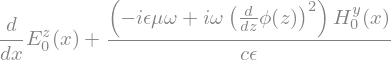

In [5]:
diff_eqs_0_new[1].lhs.collect(H_symbols[0][1](x), sp.ratsimp)

In [6]:
diff_eqs_0_new = list_subs(diff_eqs_0_new, {omega/c:k})

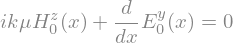

In [7]:
(sp.Eq(diff_eqs_0_new[0].lhs.collect(H_symbols[0][1](x), sp.simplify), 0))

In [8]:
sp.print_latex(sp.Eq(diff_eqs_0_new[0].lhs.collect(H_symbols[0][1](x), sp.simplify), 0))
sp.print_latex(sp.Eq(diff_eqs_0_new[1].lhs.collect(H_symbols[0][1](x), sp.simplify), 0))
sp.print_latex(sp.Eq(diff_eqs_0_new[2].lhs.collect(H_symbols[0][1](x), sp.simplify), 0))
sp.print_latex(sp.Eq(diff_eqs_0_new[3].lhs.collect(E_symbols[0][1](x), sp.simplify), 0))

i k \mu H^{z}_{0}{\left(x \right)} + \frac{d}{d x} E^{y}_{0}{\left(x \right)} = 0
\frac{d}{d x} E^{z}_{0}{\left(x \right)} + \frac{i k \left(- \epsilon \mu + \left(\frac{d}{d z} \phi{\left(z \right)}\right)^{2}\right) H^{y}_{0}{\left(x \right)}}{\epsilon} = 0
i \epsilon k E^{z}_{0}{\left(x \right)} - \frac{d}{d x} H^{y}_{0}{\left(x \right)} = 0
\frac{i k \left(\epsilon \mu - \left(\frac{d}{d z} \phi{\left(z \right)}\right)^{2}\right) E^{y}_{0}{\left(x \right)}}{\mu} + \frac{d}{d x} H^{z}_{0}{\left(x \right)} = 0


In [9]:
sp.print_latex(sp.simplify(ode0_A).subs({omega/c:k, -epsilon*mu+sp.diff(phi(z),z)**2:eta(z)}))

\left[\begin{matrix}0 & 0 & 0 & - i k \mu\\0 & 0 & - \frac{i k \eta{\left(z \right)}}{\epsilon} & 0\\0 & i \epsilon k & 0 & 0\\\frac{i k \eta{\left(z \right)}}{\mu} & 0 & 0 & 0\end{matrix}\right]


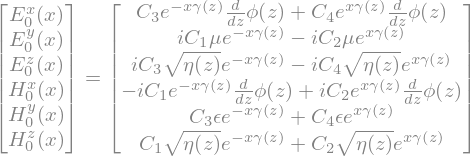

In [10]:
sp.Eq(sp.Matrix([eq.lhs for eq in sols_0]), sp.Matrix([eq.rhs.expand() for eq in sols_0]))

In [11]:
sols_0_new = [sols_0[i] for i in [1,2,4,5]]

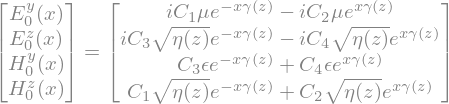

In [12]:
sp.Eq(sp.Matrix([eq.lhs for eq in sols_0_new]), sp.Matrix([eq.rhs.expand() for eq in sols_0_new]))

In [13]:
v0_1 = sp.Matrix([eq.rhs.expand().coeff(sp.Symbol("C1")*sp.exp(-x*gamma(z))) for eq in sols_0_new])
v0_2 = sp.Matrix([eq.rhs.expand().coeff(sp.Symbol("C2")*sp.exp(x*gamma(z))) for eq in sols_0_new])
v0_3 = sp.Matrix([eq.rhs.expand().coeff(sp.Symbol("C3")*sp.exp(-x*gamma(z))) for eq in sols_0_new])
v0_4 = sp.Matrix([eq.rhs.expand().coeff(sp.Symbol("C4")*sp.exp(x*gamma(z))) for eq in sols_0_new])

In [14]:
sp.print_latex(v0_1)
sp.print_latex(v0_2)
sp.print_latex(v0_3)
sp.print_latex(v0_4)

\left[\begin{matrix}i \mu\\0\\0\\\sqrt{\eta{\left(z \right)}}\end{matrix}\right]
\left[\begin{matrix}- i \mu\\0\\0\\\sqrt{\eta{\left(z \right)}}\end{matrix}\right]
\left[\begin{matrix}0\\i \sqrt{\eta{\left(z \right)}}\\\epsilon\\0\end{matrix}\right]
\left[\begin{matrix}0\\- i \sqrt{\eta{\left(z \right)}}\\\epsilon\\0\end{matrix}\right]


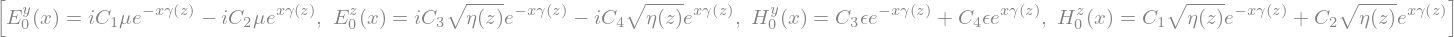

In [15]:
sols_0_new

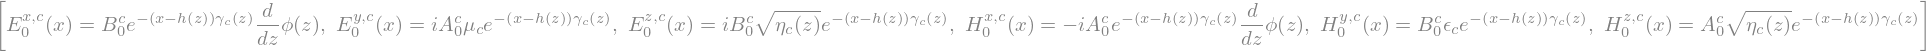

In [16]:
sols_0_layers['c']

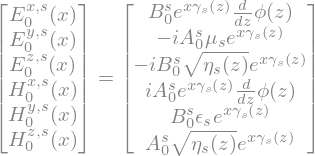

In [17]:
sp.Eq(sp.Matrix([eq.lhs for eq in sols_0_layers['s']]), sp.Matrix([eq.rhs for eq in sols_0_layers['s']]))

In [18]:
sols_0_layers['s'][2]

In [19]:
sp.print_latex(sym_coeffs_0)

\left[ A^{c}_{0}, \  A^{f}_{0}, \  B^{f}_{0}, \  A^{s}_{0}, \  B^{c}_{0}, \  C^{f}_{0}, \  D^{f}_{0}, \  B^{s}_{0}\right]


In [20]:
sp.print_latex(sp.BlockMatrix([[sp.MatrixSymbol('M1', 4, 4), sp.zeros(4,4)], [sp.zeros(4,4), sp.MatrixSymbol('M2', 4, 4)]]))

\left[\begin{matrix}M_{1} & \left[\begin{matrix}0 & 0 & 0 & 0\\0 & 0 & 0 & 0\\0 & 0 & 0 & 0\\0 & 0 & 0 & 0\end{matrix}\right]\\\left[\begin{matrix}0 & 0 & 0 & 0\\0 & 0 & 0 & 0\\0 & 0 & 0 & 0\\0 & 0 & 0 & 0\end{matrix}\right] & M_{2}\end{matrix}\right]


In [21]:
sp.print_latex(sp.simplify(M_0_TM))

\left[\begin{matrix}- i \sqrt{\eta_{c}{\left(z \right)}} - \frac{d}{d z} h{\left(z \right)} \frac{d}{d z} \phi{\left(z \right)} & \left(i \sqrt{\eta_{f}{\left(z \right)}} + \frac{d}{d z} h{\left(z \right)} \frac{d}{d z} \phi{\left(z \right)}\right) e^{- \gamma_{f}{\left(z \right)} h{\left(z \right)}} & \left(- i \sqrt{\eta_{f}{\left(z \right)}} + \frac{d}{d z} h{\left(z \right)} \frac{d}{d z} \phi{\left(z \right)}\right) e^{\gamma_{f}{\left(z \right)} h{\left(z \right)}} & 0\\\epsilon_{c} & - \epsilon_{f} e^{- \gamma_{f}{\left(z \right)} h{\left(z \right)}} & - \epsilon_{f} e^{\gamma_{f}{\left(z \right)} h{\left(z \right)}} & 0\\0 & - i \sqrt{\eta_{f}{\left(z \right)}} - \frac{d}{d z} h{\left(z \right)} \frac{d}{d z} \phi{\left(z \right)} & i \sqrt{\eta_{f}{\left(z \right)}} - \frac{d}{d z} h{\left(z \right)} \frac{d}{d z} \phi{\left(z \right)} & - i \sqrt{\eta_{s}{\left(z \right)}} + \frac{d}{d z} h{\left(z \right)} \frac{d}{d z} \phi{\left(z \right)}\\0 & \epsilon_{f} & \epsilon_{f} 

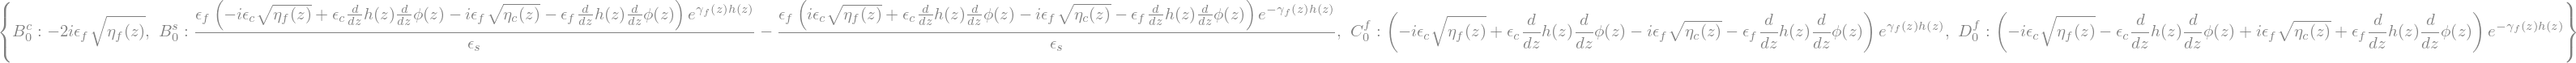

In [22]:
sol_coeffs_0_TM[1]

In [23]:
idx = 7
rr = sp.Eq(sym_coeffs_0[idx], sol_coeffs_0_TM[1][sym_coeffs_0[idx]].expand()
      .collect([sp.exp(-sp.Wild('w')),sp.exp(sp.Wild('w'))], 
               lambda *args: sp.collect(sp.combsimp(*args), sp.diff(h(z))*sp.diff(phi(z)))))

rr
sp.print_latex(rr)

B^{s}_{0} = \frac{\epsilon_{f} \left(- i \epsilon_{c} \sqrt{\eta_{f}{\left(z \right)}} - i \epsilon_{f} \sqrt{\eta_{c}{\left(z \right)}} + \left(\epsilon_{c} - \epsilon_{f}\right) \frac{d}{d z} h{\left(z \right)} \frac{d}{d z} \phi{\left(z \right)}\right) e^{\gamma_{f}{\left(z \right)} h{\left(z \right)}}}{\epsilon_{s}} - \frac{\epsilon_{f} \left(i \epsilon_{c} \sqrt{\eta_{f}{\left(z \right)}} - i \epsilon_{f} \sqrt{\eta_{c}{\left(z \right)}} + \left(\epsilon_{c} - \epsilon_{f}\right) \frac{d}{d z} h{\left(z \right)} \frac{d}{d z} \phi{\left(z \right)}\right) e^{- \gamma_{f}{\left(z \right)} h{\left(z \right)}}}{\epsilon_{s}}


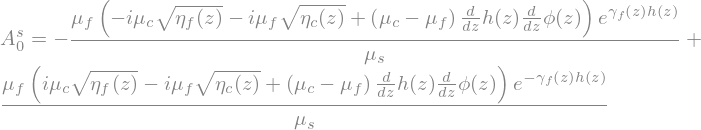

In [24]:
idx = 3
sp.Eq(sym_coeffs_0[idx], sol_coeffs_0_TE[0][sym_coeffs_0[idx]].expand()
      .collect([sp.exp(-sp.Wild('w')),sp.exp(sp.Wild('w'))], lambda *args: sp.collect(sp.combsimp(*args), sp.diff(h(z))*sp.diff(phi(z)))))

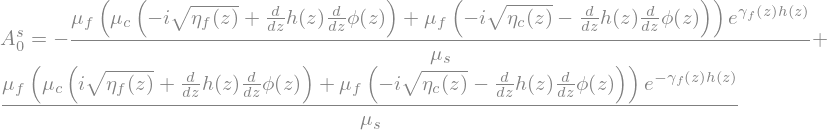

In [25]:
sp.Eq(sym_coeffs_0[idx], sol_coeffs_0_TE[0][sym_coeffs_0[idx]].expand()
      .collect([sp.exp(-sp.Wild('w')),sp.exp(sp.Wild('w'))], 
               lambda *args: sp.collect(sp.combsimp(*args), [sp.Symbol('mu_c'),sp.Symbol('mu_f')])))

### 1st order

In [82]:
eqs_1, alg_eqs_1, diff_eqs_1 = gen_maxwell_eqs(
    R,
    delop,
    phi,
    E_symbols,
    H_symbols,
    E_vec_comps,
    H_vec_comps,
    E_asympt,
    H_asympt,
    order=1,
    prev_order_eqs=list_subs(
        eqs_0, gen_vars_subs([E_symbols[0], H_symbols[0]], [x], [x, y, z])
    ),
)

# derivs_subs = {
#     sp.Derivative(E_symbols[0][0](x, z), z): sp.Function("S_1")(x, z),
#     sp.Derivative(H_symbols[0][1](x, z), z): sp.Function("S_2")(x, z),
#     sp.Derivative(H_symbols[0][0](x, z), z): sp.Function("S_3")(x, z),
#     sp.Derivative(E_symbols[0][1](x, z), z): sp.Function("S_4")(x, z),
# }

eqs_1 = list_subs(
    eqs_1,
    gen_vars_subs([E_symbols[1], H_symbols[1]], [x, y, z], [x])
    | gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x, z]),
    # | derivs_subs,
)
alg_eqs_1 = list_subs(
    alg_eqs_1,
    gen_vars_subs([E_symbols[1], H_symbols[1]], [x, y, z], [x])
    | gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x, z]),
    # | derivs_subs,
)
diff_eqs_1 = list_subs(
    diff_eqs_1,
    gen_vars_subs([E_symbols[1], H_symbols[1]], [x, y, z], [x])
    | gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x, z]),
    # | derivs_subs,
)

# save_latex_as_image(diff_eqs_1, "diff_eqs_1")

diff_sols_1 = dsolve_system(
    # list_subs(diff_eqs_1, derivs_subs),
    diff_eqs_1,
    funcs=[
        E_symbols[1][1](x),
        E_symbols[1][2](x),
        H_symbols[1][1](x),
        H_symbols[1][2](x),
    ],
    t=x,
)[0]

print("1: Found solution to ODE system")

# NOTE: A *LOT* of compute time to check
#assert check_sols(diff_eqs_1, diff_sols_1) == [True, True, True, True]
#print("1: checked if the solution is correct")

sols_1 = [
    alg_eqs_1[0].subs({eq.lhs: eq.rhs for eq in diff_sols_1}),
    diff_sols_1[0],
    diff_sols_1[1],
    alg_eqs_1[1].subs({eq.lhs: eq.rhs for eq in diff_sols_1}),
    diff_sols_1[2],
    diff_sols_1[3],
]

gamma_1 = sp.Function("gammatilde")  # in first order gamma is different from zeroth
sols_1 = list_subs(
    sols_1,
    {
        omega / c * sp.sqrt(-epsilon * mu + sp.diff(phi(z), z) ** 2): gamma_1(z),
        -epsilon * mu + sp.diff(phi(z), z) ** 2: eta(z),
    },
    eval=False,
)

sols_1 = [
    eq.replace(sp.Integral, lambda *args: sp.simplify(sp.Integral(*args)))
    for eq in sols_1
]
save_latex_as_image(sols_1, "solution_1st_order")

# sub particular part of the ode soluiton to avoid dealing with integrals
U_p_symbols = [
    sp.Function(f"{U}^{{{i}}}_p")(x, z) for U, i in product(["E", "H"], [x, y, z])
]
sols_1_particular_part = {
    sol.rhs.expand()
    - sum(
        filter(lambda e: e.has(*sp.symbols("C1 C2 C3 C4")), sol.rhs.expand().args)
    ): U_p_symbols[i]
    for i, sol in enumerate(sols_1)
}
sols_1_with_p = [sol.expand().subs(sols_1_particular_part) for sol in sols_1]

1: Found solution to ODE system


### prepare solution to ode problem

In [27]:
diff_eqs_1_new = [sp.Eq((eq.lhs*(omega/sp.I)).expand(), 0) for eq in diff_eqs_1]

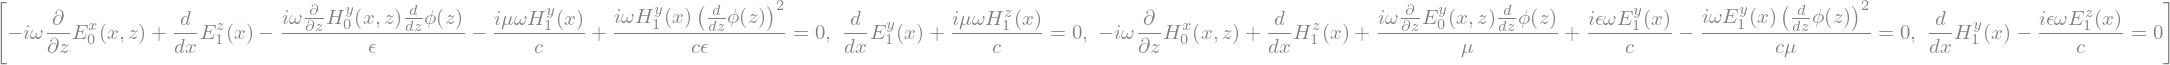

In [28]:
diff_eqs_1_new

In [29]:
diff_eqs_1_new = list_subs(diff_eqs_1_new, {omega/c:k}, eval=False)

In [30]:
sp.print_latex(sp.Eq(diff_eqs_1_new[0].lhs.collect([sp.I*k*H_symbols[1][1](x), sp.I*omega], sp.cancel), 0))
sp.print_latex(sp.Eq(diff_eqs_1_new[1].lhs, 0))
sp.print_latex(sp.Eq(diff_eqs_1_new[2].lhs.collect([sp.I*k*E_symbols[1][1](x), sp.I*omega], sp.cancel), 0))
sp.print_latex(sp.Eq(diff_eqs_1_new[3].lhs, 0))
#sp.Eq(diff_eqs_1_new[1].lhs, 0)
#sp.Eq(diff_eqs_1_new[2].lhs.collect([sp.I*k*E_symbols[1][1](x), sp.I*omega], sp.cancel), 0)
#sp.Eq(diff_eqs_1_new[3].lhs, 0)

\frac{d}{d x} E^{z}_{1}{\left(x \right)} + \frac{i k \left(- \epsilon \mu + \left(\frac{d}{d z} \phi{\left(z \right)}\right)^{2}\right) H^{y}_{1}{\left(x \right)}}{\epsilon} + \frac{i \omega \left(- \epsilon \frac{\partial}{\partial z} E^{x}_{0}{\left(x,z \right)} - \frac{\partial}{\partial z} H^{y}_{0}{\left(x,z \right)} \frac{d}{d z} \phi{\left(z \right)}\right)}{\epsilon} = 0
i k \mu H^{z}_{1}{\left(x \right)} + \frac{d}{d x} E^{y}_{1}{\left(x \right)} = 0
\frac{i k \left(\epsilon \mu - \left(\frac{d}{d z} \phi{\left(z \right)}\right)^{2}\right) E^{y}_{1}{\left(x \right)}}{\mu} + \frac{d}{d x} H^{z}_{1}{\left(x \right)} + \frac{i \omega \left(- \mu \frac{\partial}{\partial z} H^{x}_{0}{\left(x,z \right)} + \frac{\partial}{\partial z} E^{y}_{0}{\left(x,z \right)} \frac{d}{d z} \phi{\left(z \right)}\right)}{\mu} = 0
- i \epsilon k E^{z}_{1}{\left(x \right)} + \frac{d}{d x} H^{y}_{1}{\left(x \right)} = 0


In [31]:
H_symbols[1][1](x)

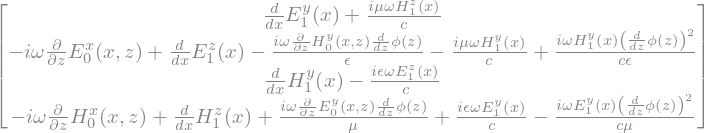

In [32]:
# order change
diff_eqs_1_new = [sp.expand(omega/sp.I*diff_eqs_1[i].lhs.expand()) for i in [1,0,3,2]]
# U.diff(x)-A*U=q
# ee should be identity matrix
# ode0_A == ode_A1
(ee, ode1_A), q1 = linear_ode_to_matrix(diff_eqs_1_new, [
        E_symbols[1][1](x),
        E_symbols[1][2](x),
        H_symbols[1][1](x),
        H_symbols[1][2](x),
    ], x, 1)
sp.expand(sp.Matrix([
        E_symbols[1][1](x),
        E_symbols[1][2](x),
        H_symbols[1][1](x),
        H_symbols[1][2](x),
    ]).diff(x)-ode1_A*sp.Matrix([
        E_symbols[1][1](x),
        E_symbols[1][2](x),
        H_symbols[1][1](x),
        H_symbols[1][2](x),
    ]))-q1

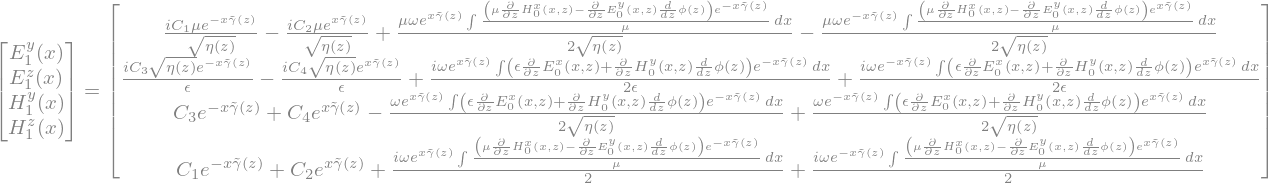

In [33]:
sols_1_new = [sols_1[i] for i in [1,2,4,5]]
sp.Eq(sp.Matrix([eq.lhs for eq in sols_1_new]), sp.Matrix([eq.rhs for eq in sols_1_new]))

In [34]:
v1_1 = sp.Matrix([eq.rhs.expand().coeff(sp.Symbol("C1")*sp.exp(-x*gamma_1(z))) for eq in sols_1_new])
v1_2 = sp.Matrix([eq.rhs.expand().coeff(sp.Symbol("C2")*sp.exp(x*gamma_1(z))) for eq in sols_1_new])
v1_3 = sp.Matrix([eq.rhs.expand().coeff(sp.Symbol("C3")*sp.exp(-x*gamma_1(z))) for eq in sols_1_new])
v1_4 = sp.Matrix([eq.rhs.expand().coeff(sp.Symbol("C4")*sp.exp(x*gamma_1(z))) for eq in sols_1_new])

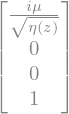

In [35]:
v1_1

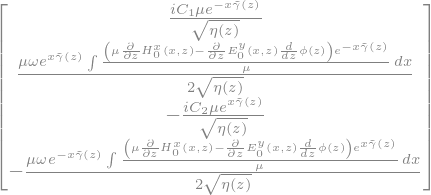

In [36]:
sp.Matrix(sols_1_new[0].rhs.args)

In [37]:
sols_1_particular_part = {
    sol.rhs
    - sum(
        filter(lambda e: e.has(*sp.symbols("C1 C2 C3 C4")), sol.rhs.expand().args)
    ): U_p_symbols[i]
    for i, sol in enumerate(sols_1)
}
aaa = [sp.Eq(value,key) for key, value in sols_1_particular_part.items()]
aaa = [aaa[i] for i in [1,2,4,5]]

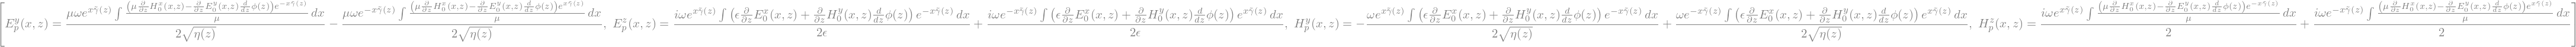

In [38]:
aaa

In [39]:
subs_1 = {eq:sp.Function(f'P{i+1}')(x,z) for i, eq in enumerate(aaa[0].find(sp.Integral, group=True).keys())}
subs_1.update({eq:sp.Function(f'P{i+3}')(x,z) for i, eq in enumerate(aaa[1].find(sp.Integral, group=True).keys())})

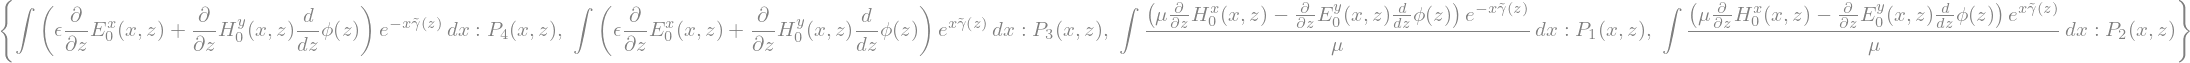

In [40]:
subs_1

In [41]:
ints = list(subs_1.keys())

In [42]:
ints_subs = {ints[0]:-1/mu*sp.Integral(sp.combsimp(sum([eq.args[0] for eq in ints[0].doit().find(sp.Integral)])),x),
            ints[1]:-1/mu*sp.Integral(sp.combsimp(sum([eq.args[0] for eq in ints[1].doit().find(sp.Integral)])),x)}

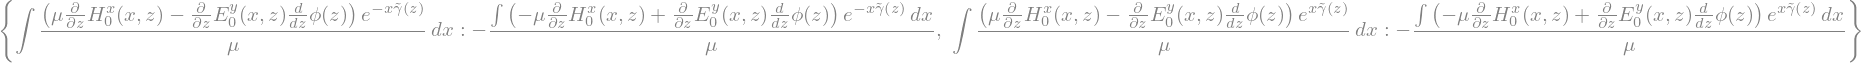

In [43]:
ints_subs

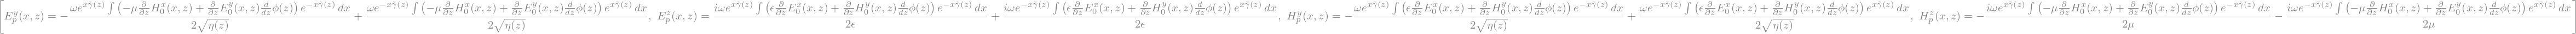

In [44]:
aaa = list_subs(aaa, ints_subs, eval=False)
aaa

In [45]:
subs_1 = {eq:sp.Function(f'P{i+1}')(x,z) for i, eq in enumerate(aaa[0].find(sp.Integral, group=True).keys())}
subs_1.update({eq:sp.Function(f'P{i+3}')(x,z) for i, eq in enumerate(aaa[1].find(sp.Integral, group=True).keys())})

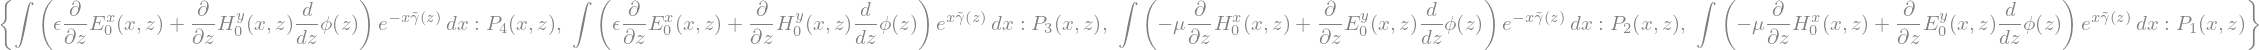

In [46]:
subs_1

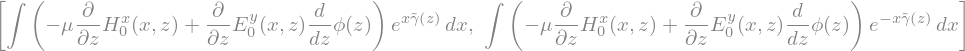

In [47]:
list(aaa[0].find(sp.Integral, group=True).keys())

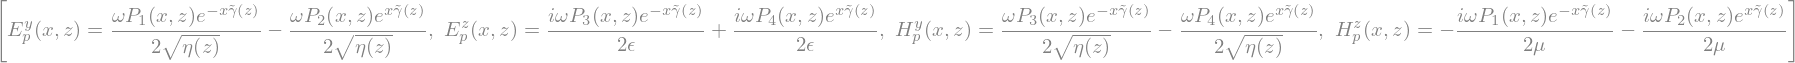

In [48]:
list_subs(aaa, subs_1, eval=False)

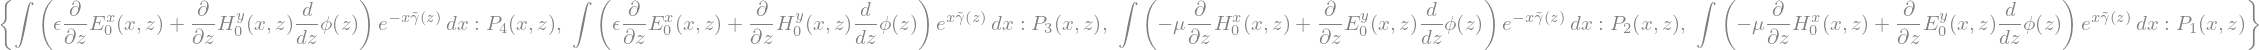

In [49]:
subs_1

In [50]:
aaa_subsed = list_subs(aaa, subs_1, eval=False)
# preview_collection(aaa_subsed)
a_symbols = [sp.Symbol(f'a{i+1}') for i in range(4)]
P_coeffs = {omega/(2*sp.sqrt(eta(z))): a_symbols[0],
           sp.I*omega/(2*epsilon): a_symbols[1], 
           sp.I*omega/(2*mu): a_symbols[2]}
aaa_subsed = list_subs(aaa_subsed, P_coeffs, eval=False)

In [51]:
sp.print_latex([sp.Eq(value, key) for key, value in P_coeffs.items()])

\left[ a_{1} = \frac{\omega}{2 \sqrt{\eta{\left(z \right)}}}, \  a_{2} = \frac{i \omega}{2 \epsilon}, \  a_{3} = \frac{i \omega}{2 \mu}\right]


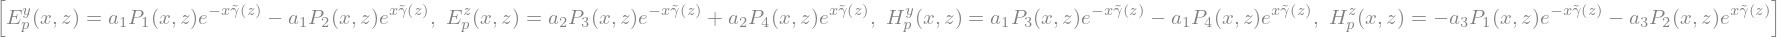

In [52]:
(aaa_subsed)

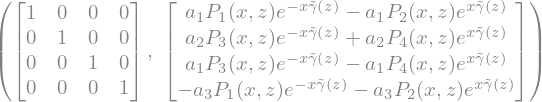

In [53]:
sp.linear_eq_to_matrix(aaa_subsed, [eq.lhs for eq in aaa_subsed])

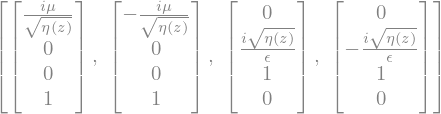

In [54]:
[v1_1, v1_2, v1_3, v1_4]

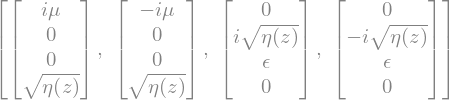

In [55]:
[v0_1, v0_2, v0_3, v0_4]

In [56]:
sp.print_latex(sp.Matrix([eq.rhs.coeff(sp.exp(gamma_1(z)*x)) for eq in aaa_subsed]))

\left[\begin{matrix}- a_{1} P_{2}{\left(x,z \right)}\\a_{2} P_{4}{\left(x,z \right)}\\- a_{1} P_{4}{\left(x,z \right)}\\- a_{3} P_{2}{\left(x,z \right)}\end{matrix}\right]


In [57]:
sp.print_latex(sp.Matrix([eq.rhs.coeff(sp.exp(-gamma_1(z)*x)) for eq in aaa_subsed]))

\left[\begin{matrix}a_{1} P_{1}{\left(x,z \right)}\\a_{2} P_{3}{\left(x,z \right)}\\a_{1} P_{3}{\left(x,z \right)}\\- a_{3} P_{1}{\left(x,z \right)}\end{matrix}\right]


### SLAE

In [83]:
sols_1_with_p = list_subs(
    sols_1_with_p, {sp.Symbol('C1'):sp.Symbol('C1')*sp.sqrt(eta(z)),
    sp.Symbol('C2'):sp.Symbol('C2')*sp.sqrt(eta(z)),
    sp.Symbol('C3'):sp.Symbol('C3')*epsilon,
    sp.Symbol('C4'):sp.Symbol('C4')*epsilon}, eval=False)

sols_1_layers = {
    layer: layered_sols(sols_1_with_p, layer, order=1) for layer in ["c", "f", "s"]
}
sols_1_layers['c'] = list_subs(sols_1_layers['c'], 
          {sym_coeffs_1[4]:sym_coeffs_1[4]*sp.exp(sp.Function('gammatilde_c')(z)*sp.Function("h")(z)),
          sym_coeffs_1[0]:sym_coeffs_1[0]*sp.exp(sp.Function('gammatilde_c')(z)*sp.Function("h")(z))})

save_latex_as_image(sols_1_layers["c"], "sols_1_cover")
save_latex_as_image(sols_1_layers["f"], "sols_1_film")
save_latex_as_image(sols_1_layers["s"], "sols_1_substrate")

print("1: reconstructed ODE solution to hide particular part")

# Now solving for 2D waveguide with smoothly irregular transition, x=h(z)

# boundry conditions
h = sp.Function("h")
border_func = R.x - h(R.z)

E_boundry_cf_1 = gen_boundry_conds(
    R, delop, E_vec_comps[1], border_func, h(z), ["c", "f"], order=1
)

H_boundry_cf_1 = gen_boundry_conds(
    R, delop, H_vec_comps[1], border_func, h(z), ["c", "f"], order=1
)

E_boundry_fs_1 = gen_boundry_conds(
    R, delop, E_vec_comps[1], border_func, 0, ["f", "s"], order=1
)

H_boundry_fs_1 = gen_boundry_conds(
    R, delop, H_vec_comps[1], border_func, 0, ["f", "s"], order=1
)

boundry_eqs_1 = list_subs(
    E_boundry_cf_1 + H_boundry_cf_1 + E_boundry_fs_1 + H_boundry_fs_1,
    {
        eq.lhs: eq.rhs
        for eq in list_subs(
            sols_1_layers["c"] + sols_1_layers["f"], {x: h(z)}, eval=False
        )
        + list_subs(sols_1_layers["f"] + sols_1_layers["s"], {x: 0}, eval=False)
    },
    eval=False,
)
print("1: construct boundry conditions in general form")

# order is intentional to produce block-diagonal matrix
sym_coeffs_1 = [
    # TE
    sp.Symbol("A_1^c"),
    sp.Symbol("A_1^f"),
    sp.Symbol("B_1^f"),
    sp.Symbol("A_1^s"),
    # TM
    sp.Symbol("B_1^c"),
    sp.Symbol("C_1^f"),
    sp.Symbol("D_1^f"),
    sp.Symbol("B_1^s"),
]

# reorder equations to block-diagonal matrix of coefficients
new_ord = [1, 2, 5, 6, 0, 3, 4, 7]
boundry_eqs_1 = [boundry_eqs_1[i] for i in new_ord]
M_1, _ = sp.linear_eq_to_matrix(boundry_eqs_1, sym_coeffs_1)

# preview(
#     (M_1, b),
#     output="png",
#     dvioptions=["-D 200"],
#     euler=False,
# )

M_1_TE = M_1[:4, :4]
sym_coeffs_1_TE = sym_coeffs_1[:4]

q_TE = sp.Matrix([sp.Symbol(f"q_{i}") for i in range(1, 5)])
d_q_TE = q_TE.to_DM()

d_M_1_TE = M_1_TE.to_DM()

sol_coeffs_1_TE, det_1_TE = d_M_1_TE.solve_den_charpoly(d_q_TE)
sol_coeffs_1_TE = sol_coeffs_1_TE.to_Matrix()
sol_coeffs_1_TE = sp.Matrix(
    [sol_coeffs_1_TE[i].expand().combsimp() for i in range(4)]
)
det_1_TE = det_1_TE.expand().combsimp()

# assert sp.expand((d_M_1_TE * sol_coeffs_1_TE.to_DM()).to_Matrix()) - sp.expand(
#     sp.Matrix([det_1_TE * i for i in q_TE])
# )
print(f"1: found and checked coefficients TE-mode:{sym_coeffs_1_TE}")

save_latex_as_image(det_1_TE, "determinant_1_TE")
save_latex_as_image(sol_coeffs_1_TE, "coeffs_1_TE")

M_1_TM = M_1[4:, 4:]
sym_coeffs_1_TM = sym_coeffs_1[4:]
d_M_1_TM = M_1_TM.to_DM()

q_TM = sp.Matrix([sp.Symbol(f"q_{i}") for i in range(5, 9)])
d_q_TM = q_TM.to_DM()

d_M_1_TM = M_1_TM.to_DM()

sol_coeffs_1_TM, det_1_TM = d_M_1_TM.solve_den_charpoly(d_q_TM)
sol_coeffs_1_TM = sol_coeffs_1_TM.to_Matrix()
sol_coeffs_1_TM = sp.Matrix(
    [sol_coeffs_1_TM[i].expand().combsimp() for i in range(4)]
)

det_1_TM = det_1_TM.expand().combsimp()
# assert sp.expand((d_M_1_TM * sol_coeffs_1_TM.to_DM()).to_Matrix()) - sp.expand(
#     sp.Matrix([det_1_TM * i for i in q_TM])
# )

print(f"1: found and checked coefficients TM-mode:{sym_coeffs_1_TM}")

save_latex_as_image(det_1_TM, "determinant_1_TM")
save_latex_as_image(sol_coeffs_1_TM, "coeffs_1_TM")
    

1: reconstructed ODE solution to hide particular part
1: construct boundry conditions in general form
1: found and checked coefficients TE-mode:[A_1^c, A_1^f, B_1^f, A_1^s]
1: found and checked coefficients TM-mode:[B_1^c, C_1^f, D_1^f, B_1^s]


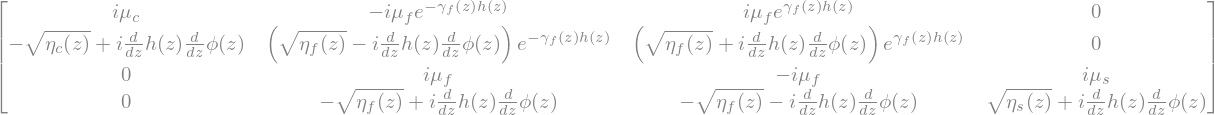

In [84]:
sp.simplify(M_0_TE)

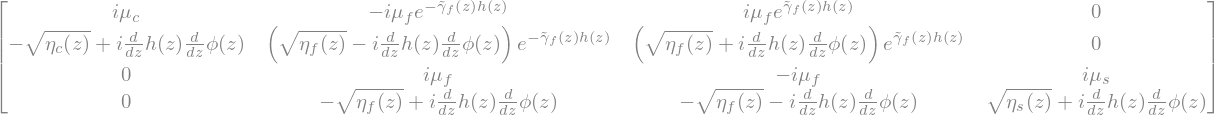

In [85]:
sp.simplify(M_1_TE)

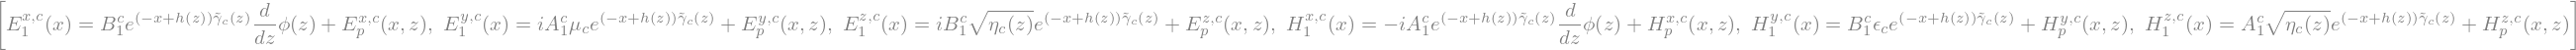

In [86]:
[sp.Eq(eq.lhs, eq.rhs.powsimp()) for eq in sols_1_layers['c']]

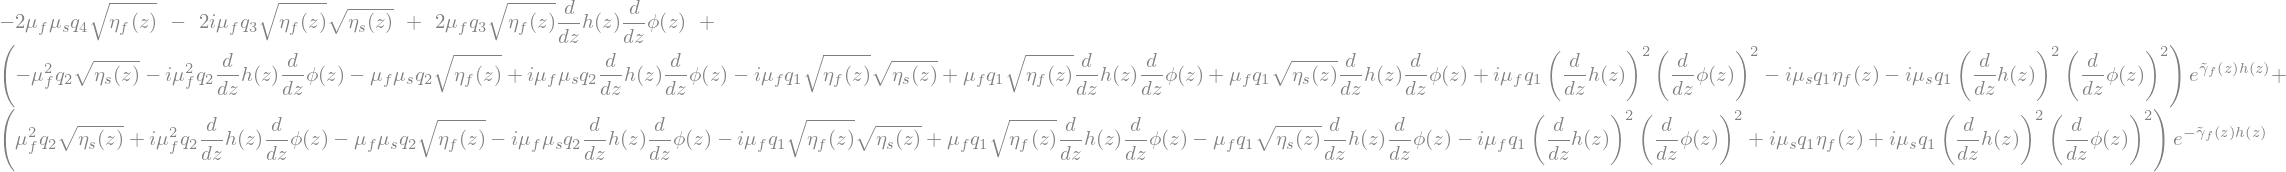

In [88]:
sol_coeffs_1_TE[0].expand().collect(sp.exp(h(z)*sp.Function(f"gammatilde_f")(z)))

In [ ]:
sol_coeffs_1_TE[1].expand().powsimp().collect(
    [sp.exp(h(z)*sp.Function(f"gammatilde_c")(z)),
     sp.exp(h(z)*(-sp.Function(f"gammatilde_c")(z)+sp.Function(f"gammatilde_f")(z)))])

In [ ]:
sol_coeffs_1_TE[2].expand().powsimp().collect(
   sol_coeffs_1_TE[2].expand().powsimp().find(sp.exp))

In [ ]:
sol_coeffs_1_TE[2].expand().powsimp().collect(
   sol_coeffs_1_TE[2].expand().powsimp().find(sp.exp))

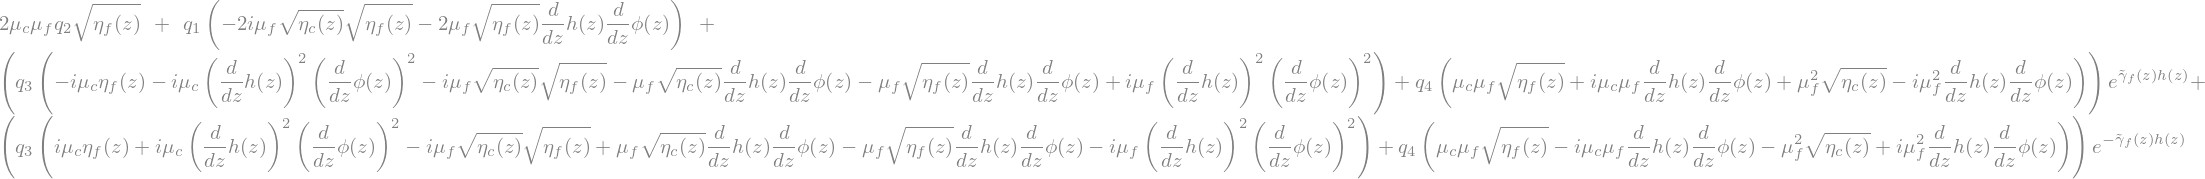

In [92]:
sol_coeffs_1_TE[3].expand().powsimp().collect(
   sol_coeffs_1_TE[3].expand().powsimp().find(sp.exp), 
    lambda *args: sp.collect(*args,[sp.Symbol(f"q_{i}") for i in range(1, 5)]))

In [ ]:
sol_coeffs_1_TE[3].expand().powsimp().collect(
   sol_coeffs_1_TE[3].expand().powsimp().find(sp.exp)).args

In [ ]:
sol_coeffs_1_TM[0].expand().powsimp().collect(
   sol_coeffs_1_TM[0].expand().powsimp().find(sp.exp))

In [ ]:
sol_coeffs_1_TM[1].expand().powsimp().collect(
   sol_coeffs_1_TM[1].expand().powsimp().find(sp.exp))

In [89]:
print_1_TE = [eq.expand().powsimp().collect(
    eq.expand().powsimp().find(sp.exp)) for eq in sol_coeffs_1_TE]
print_1_TM = [eq.expand().powsimp().collect(
    eq.expand().powsimp().find(sp.exp)) for eq in sol_coeffs_1_TM]

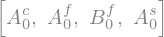

In [122]:
sym_coeffs_0_TE

In [121]:
sp.print_latex(sp.Eq(sym_coeffs_0_TM[3],sol_coeffs_1_TM[3].expand().collect([sp.exp(sp.Wild('w')),sp.exp(-sp.Wild('w'))], 
                          lambda *arg: sp.collect(*arg, [sp.diff(h(z))*sp.diff(phi(z))], sp.simplify))))

B^{s}_{0} = 2 i \epsilon_{f} q_{6} \sqrt{\eta_{f}{\left(z \right)}} \frac{d}{d z} h{\left(z \right)} \frac{d}{d z} \phi{\left(z \right)} + 2 \epsilon_{f} \left(i \epsilon_{c} q_{5} - q_{6} \sqrt{\eta_{c}{\left(z \right)}}\right) \sqrt{\eta_{f}{\left(z \right)}} + \left(i \epsilon_{c} \epsilon_{f} q_{7} \sqrt{\eta_{f}{\left(z \right)}} - \epsilon_{c} q_{8} \eta_{f}{\left(z \right)} + i \epsilon_{f}^{2} q_{7} \sqrt{\eta_{c}{\left(z \right)}} - \epsilon_{f} q_{8} \sqrt{\eta_{c}{\left(z \right)}} \sqrt{\eta_{f}{\left(z \right)}} + \epsilon_{f} \left(- \epsilon_{c} q_{7} + \epsilon_{f} q_{7} + i q_{8} \sqrt{\eta_{c}{\left(z \right)}} + i q_{8} \sqrt{\eta_{f}{\left(z \right)}}\right) \frac{d}{d z} h{\left(z \right)} \frac{d}{d z} \phi{\left(z \right)} + q_{8} \left(- \epsilon_{c} + \epsilon_{f}\right) \left(\frac{d}{d z} h{\left(z \right)}\right)^{2} \left(\frac{d}{d z} \phi{\left(z \right)}\right)^{2}\right) e^{\tilde{\gamma}_{f}{\left(z \right)} h{\left(z \right)}} + \left(i \epsilon_{c} \

In [111]:
sp.print_latex(sp.Matrix([sp.collect(eq, sp.diff(h(z),z)) for eq in _]))

\left[\begin{matrix}- E^{y,c}_p{\left(h{\left(z \right)},z \right)} + E^{y,f}_p{\left(h{\left(z \right)},z \right)}\\\left(H^{x,c}_p{\left(h{\left(z \right)},z \right)} - H^{x,f}_p{\left(h{\left(z \right)},z \right)}\right) \frac{d}{d z} h{\left(z \right)} + H^{z,c}_p{\left(h{\left(z \right)},z \right)} - H^{z,f}_p{\left(h{\left(z \right)},z \right)}\\- E^{y,f}_p{\left(0,z \right)} + E^{y,s}_p{\left(0,z \right)}\\\left(H^{x,f}_p{\left(0,z \right)} - H^{x,s}_p{\left(0,z \right)}\right) \frac{d}{d z} h{\left(z \right)} + H^{z,f}_p{\left(0,z \right)} - H^{z,s}_p{\left(0,z \right)}\\\left(E^{x,c}_p{\left(h{\left(z \right)},z \right)} - E^{x,f}_p{\left(h{\left(z \right)},z \right)}\right) \frac{d}{d z} h{\left(z \right)} + E^{z,c}_p{\left(h{\left(z \right)},z \right)} - E^{z,f}_p{\left(h{\left(z \right)},z \right)}\\- H^{y,c}_p{\left(h{\left(z \right)},z \right)} + H^{y,f}_p{\left(h{\left(z \right)},z \right)}\\\left(E^{x,f}_p{\left(0,z \right)} - E^{x,s}_p{\left(0,z \right)}\right) \frac{d

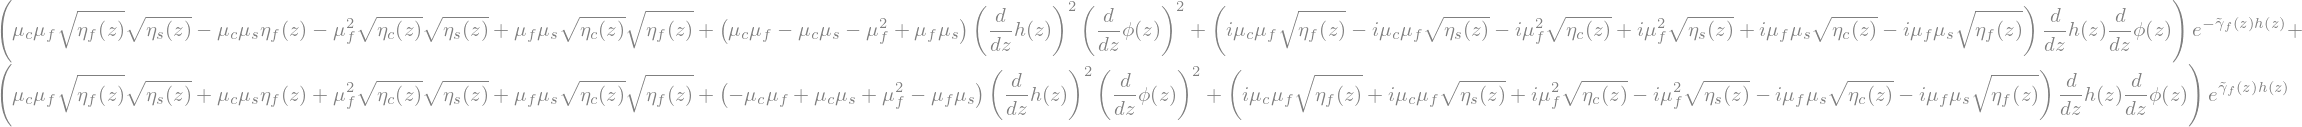

In [103]:
det_1_TE.expand().collect([sp.exp(sp.Wild('w')),sp.exp(-sp.Wild('w'))], 
                          lambda *arg: sp.collect(*arg, [sp.diff(h(z))*sp.diff(phi(z))]))

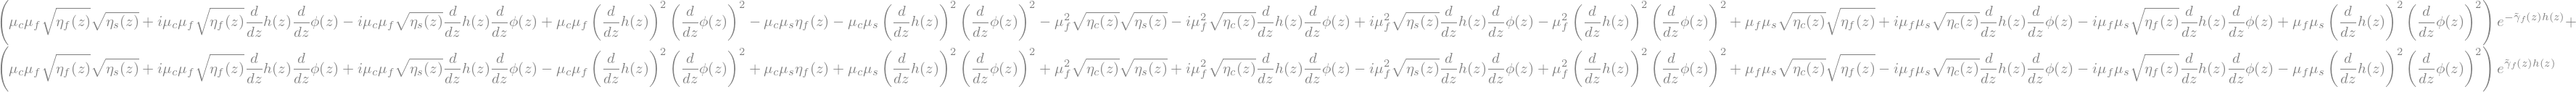

In [101]:
det_1_TE.expand().collect([sp.exp(sp.Wild('w')),sp.exp(-sp.Wild('w'))])

In [106]:
sp.print_latex(det_1_TM.expand().collect([sp.exp(sp.Wild('w')),sp.exp(-sp.Wild('w'))], 
                          lambda *arg: sp.collect(*arg, [sp.diff(h(z))*sp.diff(phi(z))], sp.simplify)))

\left(\epsilon_{c} \epsilon_{f} \sqrt{\eta_{f}{\left(z \right)}} \sqrt{\eta_{s}{\left(z \right)}} - \epsilon_{c} \epsilon_{s} \eta_{f}{\left(z \right)} - \epsilon_{f}^{2} \sqrt{\eta_{c}{\left(z \right)}} \sqrt{\eta_{s}{\left(z \right)}} + \epsilon_{f} \epsilon_{s} \sqrt{\eta_{c}{\left(z \right)}} \sqrt{\eta_{f}{\left(z \right)}} + i \epsilon_{f} \left(\epsilon_{c} \sqrt{\eta_{f}{\left(z \right)}} - \epsilon_{c} \sqrt{\eta_{s}{\left(z \right)}} - \epsilon_{f} \sqrt{\eta_{c}{\left(z \right)}} + \epsilon_{f} \sqrt{\eta_{s}{\left(z \right)}} + \epsilon_{s} \sqrt{\eta_{c}{\left(z \right)}} - \epsilon_{s} \sqrt{\eta_{f}{\left(z \right)}}\right) \frac{d}{d z} h{\left(z \right)} \frac{d}{d z} \phi{\left(z \right)} + \left(\epsilon_{c} \epsilon_{f} - \epsilon_{c} \epsilon_{s} - \epsilon_{f}^{2} + \epsilon_{f} \epsilon_{s}\right) \left(\frac{d}{d z} h{\left(z \right)}\right)^{2} \left(\frac{d}{d z} \phi{\left(z \right)}\right)^{2}\right) e^{- \tilde{\gamma}_{f}{\left(z \right)} h{\left(z \right)